# **Race/Ethnic Classification by Face using MobileNetV2**

## **Ekstrak Label/Class**

In [9]:
import pandas as pd
import os

# 1. Load file CSV
train_df = pd.read_csv('./Dataset/fairface_label_train.csv')
val_df = pd.read_csv('./Dataset/fairface_label_val.csv')

# 2. Filter hanya kolom yang dibutuhkan (file path dan race)
# Kita pastikan kolom 'file' sesuai dengan lokasi fisik gambar di folder
train_data = train_df[['file', 'race']]
val_data = val_df[['file', 'race']]

# 3. Cek distribusi label (Penting untuk melihat apakah dataset seimbang)
print("Distribusi Ras di Training:")
print(train_data['race'].value_counts())

# 4. Contoh akses data
# Jika folder 'train' berada di dalam directory yang sama dengan script:
# train_data['full_path'] = 'data_dir/' + train_data['file']

print("\nData siap diproses!")
print(train_data.head())

Distribusi Ras di Training:
race
White              16527
Latino_Hispanic    13367
Indian             12319
East Asian         12287
Black              12233
Southeast Asian    10795
Middle Eastern      9216
Name: count, dtype: int64

Data siap diproses!
          file        race
0  train/1.jpg  East Asian
1  train/2.jpg      Indian
2  train/3.jpg       Black
3  train/4.jpg      Indian
4  train/5.jpg      Indian


## **Resampling Data serta Ekstraksi Label & Setup Data Generator**

` Menggunakan jumlah gambar 800 untuk train - 200 untuk validation `

In [11]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load file CSV sesuai nama terbaru
train_df = pd.read_csv('./Dataset/fairface_label_train.csv')
val_df = pd.read_csv('./Dataset/fairface_label_val.csv')

# 1.1 Pastikan nama kolom bersih dari spasi tersembunyi
train_df.columns = train_df.columns.str.strip()
val_df.columns = val_df.columns.str.strip()

# 1.2 Verifikasi ulang setelah dibersihkan (opsional)
print("Kolom yang terdeteksi:", train_df.columns.tolist())

# 1.3 Eksekusi Strategi 1: 800 Train - 200 Validation
try:
    # Menggunakan metode .sample() bawaan groupby (Jauh lebih aman!)
    train_df_800 = train_df.groupby('race').sample(n=800, random_state=42).reset_index(drop=True)
    val_df_200 = val_df.groupby('race').sample(n=200, random_state=42).reset_index(drop=True)

    print("\n--- Berhasil Melakukan Resampling ---")
    print("Kolom di Train Baru:", train_df_800.columns.tolist()) 
    print(f"Total Data Latih Baru   : {len(train_df_800)} gambar")
    print(f"Total Data Validasi Baru: {len(val_df_200)} gambar")

except Exception as e:
    print(f"\n[ERROR] Terjadi masalah: {e}")

# 2. Setup Data Generator (Optimasi untuk RAM 5,7GB)
# Kita gunakan rescale 1/255 agar nilai piksel ada di rentang 0-1
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Parameter Penyelamat Memory
IMG_SIZE = (128, 128) 
BATCH_SIZE = 16 # Jika nanti masih terasa berat/crash, turunkan ke 8

# Generator Latih
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df_800, # <--- Gunakan df hasil sampling
    directory='Dataset',
    x_col='file',
    y_col='race',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df_200,   # <--- Gunakan df hasil sampling
    directory='Dataset',
    x_col='file',
    y_col='race',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Kolom yang terdeteksi: ['file', 'age', 'gender', 'race', 'service_test']

--- Berhasil Melakukan Resampling ---
Kolom di Train Baru: ['file', 'age', 'gender', 'race', 'service_test']
Total Data Latih Baru   : 5600 gambar
Total Data Validasi Baru: 1400 gambar
Found 5600 validated image filenames belonging to 7 classes.
Found 1400 validated image filenames belonging to 7 classes.


## **Arsitektur Model MobileNetV2 (Transfer Learning)**

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load MobileNetV2 tanpa layer output asli
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(128, 128, 3)
)

# # FREEZE: Jangan latih ulang base model agar hemat komputasi
# base_model.trainable = False 
base_model.trainable = True
# Freeze semua layer kecuali 30 layer terakhir
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Tambahkan layer baru khusus untuk klasifikasi Ras
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x) # Memberikan sedikit ruang agar model tidak kaku

# Output layer menyesuaikan jumlah ras di dataset
num_classes = len(train_generator.class_indices)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Kompilasi
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # LR lebih kecil agar stabil
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 1,691,271 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

## **Training Model**

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.2002 - auc: 0.5716 - loss: 2.0571 - precision: 0.2994 - recall: 0.0248
Epoch 1: val_accuracy improved from None to 0.25072, saving model to output/model_race_800.keras

Epoch 1: finished saving model to output/model_race_800.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 208s 560ms/step - accuracy: 0.2407 - auc: 0.6241 - loss: 1.9208 - precision: 0.4258 - recall: 0.0348 - val_accuracy: 0.2507 - val_auc: 0.6591 - val_loss: 1.9104 - val_precision: 0.3435 - val_recall: 0.0812 - learning_rate: 1.0000e-04
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.3759 - auc: 0.7539 - loss: 1.6225 - precision: 0.6365 - recall: 0.1079
Epoch 2: val_accuracy improved from 0.25072 to 0.26078, saving model to output/model_race_800.keras

Epoch 2: finished saving model to output/model_race_800.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 189s 540ms/step - accuracy: 0.3684 - auc: 0.7536 - loss: 1.6228 - precision: 0.6212 - recall: 0.1213 - val_

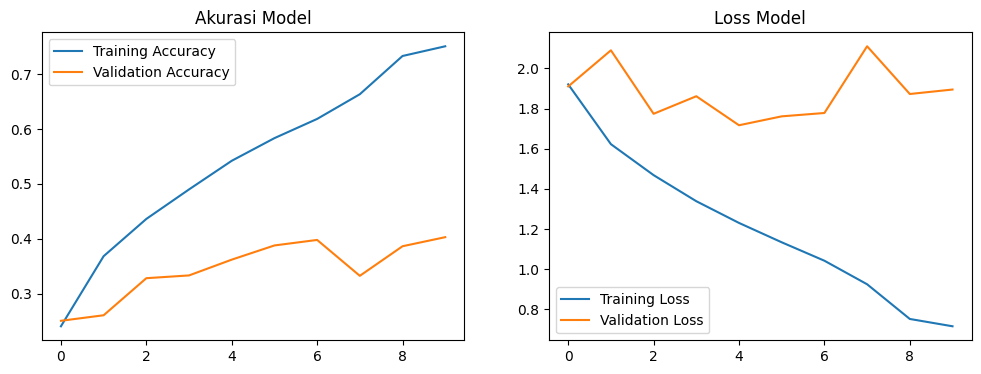

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import os
if not os.path.exists('output'):
    os.makedirs('output')

# 1. KONFIGURASI CALLBACKS
# EarlyStopping: Menghentikan training jika val_loss tidak turun selama 5 epoch berturut-turut.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Menurunkan learning rate jika akurasi mulai mentok.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6,
    verbose=1
)

# ModelCheckpoint: Otomatis menyimpan model terbaik yang berhasil dilatih.
checkpoint = ModelCheckpoint(
    'output/model_race_800.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# checkpoint = ModelCheckpoint(
#     'output/model_race_2000.keras',
#     monitor='val_accuracy',
#     save_best_only=True,
#     verbose=1
# )

# 2. PROSES TRAINING
# Kita mulai dengan 20 epoch. EarlyStopping kemungkinan akan menghentikannya lebih cepat.
EPOCHS = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# 3. VISUALISASI HASIL
# Membuat grafik Akurasi dan Loss untuk melihat performa model
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Akurasi Model')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Model')
plt.legend()
plt.show()

## **Metrik Evaluasi menggunakan Validation Data**

88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 344ms/step


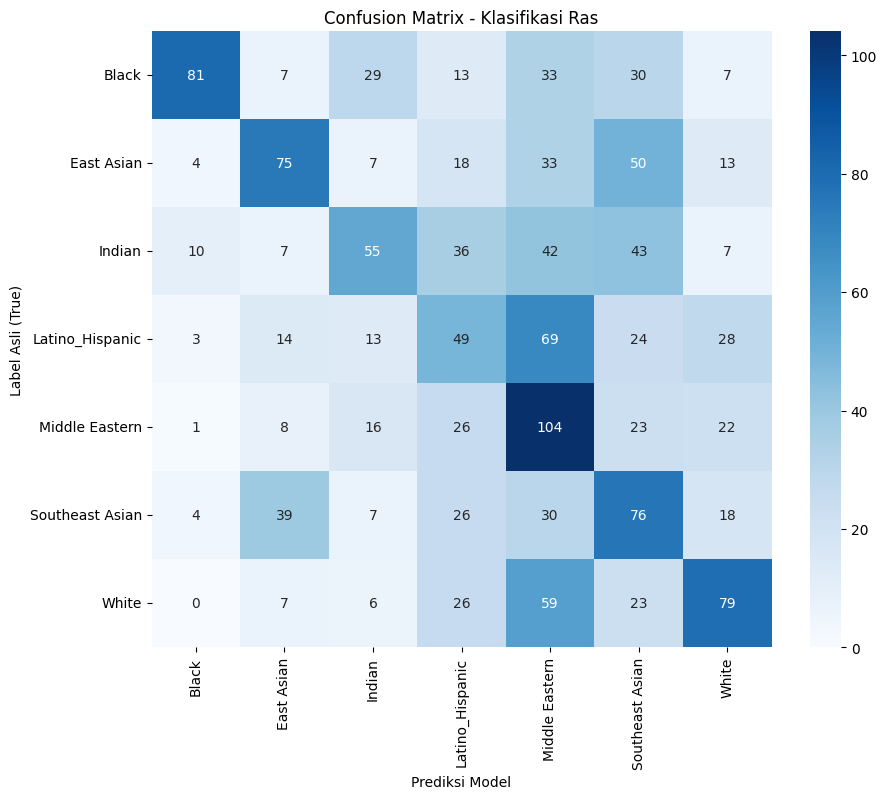


--- Laporan Klasifikasi (Metrik Evaluasi) ---
                 precision    recall  f1-score   support

          Black       0.79      0.41      0.53       200
     East Asian       0.48      0.38      0.42       200
         Indian       0.41      0.28      0.33       200
Latino_Hispanic       0.25      0.24      0.25       200
 Middle Eastern       0.28      0.52      0.36       200
Southeast Asian       0.28      0.38      0.32       200
          White       0.45      0.40      0.42       200

       accuracy                           0.37      1400
      macro avg       0.42      0.37      0.38      1400
   weighted avg       0.42      0.37      0.38      1400



In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil label asli dan prediksi dari validation generator
val_generator.reset() # Reset agar urutan tidak berantakan
Y_pred = model.predict(val_generator, steps=val_generator.samples // BATCH_SIZE + 1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 2. Ambil nama-nama kelas (Ras)
class_labels = list(val_generator.class_indices.keys())

# 3. Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Visualisasi dengan Seaborn Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ras')
plt.ylabel('Label Asli (True)')
plt.xlabel('Prediksi Model')
plt.show()

# 5. Print Metrik Evaluasi Lengkap (Precision, Recall, F1-Score)
print("\n--- Laporan Klasifikasi (Metrik Evaluasi) ---")
print(classification_report(y_true, y_pred, target_names=class_labels))